In [2]:
#saniya goutam prn:23070521126
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical




In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape data to include channel dimension (28x28 grayscale images -> 28x28x1)
X_train = X_train.reshape((60000, 28, 28, 1)).astype('float32') / 255.0
X_test = X_test.reshape((10000, 28, 28, 1)).astype('float32') / 255.0

# Encode labels to categorical (one-hot encoding)
y_train_encoded = to_categorical(y_train)
y_test_encoded = to_categorical(y_test)

In [4]:
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense Classifier Heads
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),  # Prevents overfitting
    layers.Dense(10, activation='softmax')  # 10 output classes for digits 0-9
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the network
history = model.fit(X_train, y_train_encoded,
                    epochs=5,
                    batch_size=64,
                    validation_split=0.1)

# Evaluate performance on unseen test data
test_loss, test_acc = model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"\nTest Dataset Accuracy: {test_acc:.4f}")
print(f"Test Dataset Loss: {test_loss:.4f}")


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.8737 - loss: 0.4025 - val_accuracy: 0.9802 - val_loss: 0.0668
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9501 - loss: 0.1670 - val_accuracy: 0.9848 - val_loss: 0.0475
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.9625 - loss: 0.1240 - val_accuracy: 0.9903 - val_loss: 0.0411
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9696 - loss: 0.1015 - val_accuracy: 0.9905 - val_loss: 0.0342
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.9728 - loss: 0.0859 - val_accuracy: 0.9905 - val_loss: 0.0327

Test Dataset Accuracy: 0.9898
Test Dataset Loss: 0.0345


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


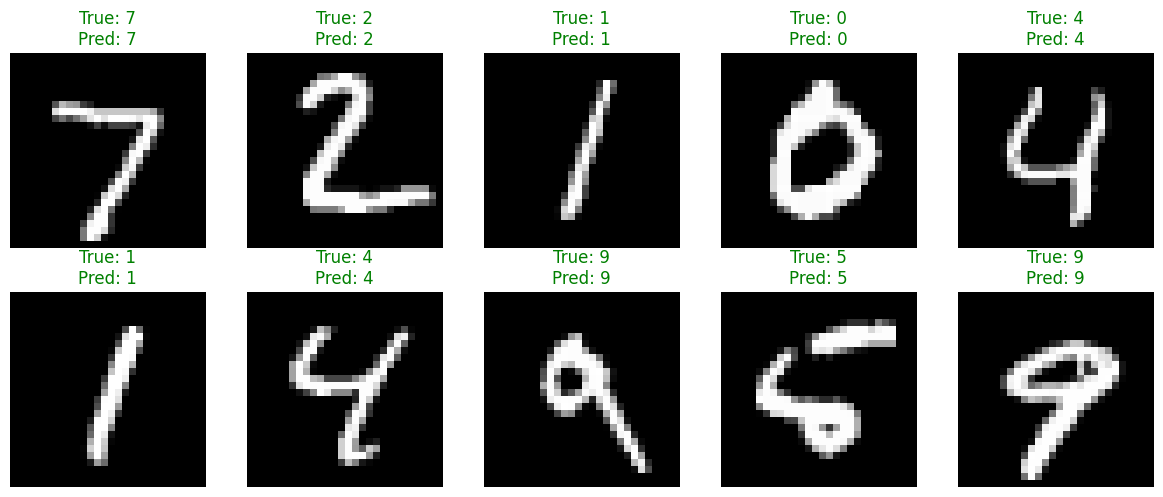

In [6]:
# Generate predictions on the test set
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Plot the first 10 test images alongside their true vs predicted labels
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    # Color text green if correct, red if incorrect
    color = 'green' if predicted_labels[i] == y_test[i] else 'red'
    plt.title(f"True: {y_test[i]}\nPred: {predicted_labels[i]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()